In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
import warnings
warnings.filterwarnings('ignore')

In [3]:
df = pd.read_csv("dry_bean_dataset.csv")

| No. | Feature | Simple Meaning | What It Tells Us |
|---:|---|---|---|
| 1 | **Area** | Total area occupied by the bean in the image | Overall size of the bean |
| 2 | **Perimeter** | Length around the outer boundary of the bean | Boundary/outline size |
| 3 | **MajorAxisLength** | Length of the bean along its longest direction | How long the bean is |
| 4 | **MinorAxisLength** | Length across the bean's shortest direction | How wide the bean is |
| 5 | **AspectRation** | Ratio of major axis to minor axis | How elongated the bean is |
| 6 | **Eccentricity** | Measures how different the bean is from a circle | Round vs. elongated shape |
| 7 | **ConvexArea** | Area of the smallest convex shape covering the bean | Irregularity of the bean boundary |
| 8 | **EquivDiameter** | Diameter of a circle having the same area as the bean | Equivalent size in circular form |
| 9 | **Extent** | Ratio of bean area to its bounding-box area | How much of the surrounding box the bean fills |
| 10 | **Solidity** | Ratio of bean area to convex area | How solid/regular the bean shape is |
| 11 | **roundness** | Measures how close the bean is to a circle | Circularity of the bean |
| 12 | **Compactness** | Measures how compact the bean is based on its area and perimeter | Overall compactness |
| 13 | **ShapeFactor1** | Mathematical ratio derived from area, perimeter and axis dimensions | Fine shape characteristics |
| 14 | **ShapeFactor2** | Mathematical shape descriptor derived from bean geometry | Shape differences between bean types |
| 15 | **ShapeFactor3** | Another mathematical descriptor of bean shape | Shape/compactness characteristics |
| 16 | **ShapeFactor4** | Mathematical descriptor related to the bean's geometric shape | Fine boundary/shape differences |
| 17 | **Class** | Name/type of the bean | **Target variable for KNN classification** |

In [4]:
object_columns = df.select_dtypes(include=['object', 'bool']).columns
print("Object type columns:")
print(object_columns)

numerical_columns = df.select_dtypes(include=['int64', 'float64']).columns
print("\nNumerical type columns:")
print(numerical_columns)

Object type columns:
Index(['Class'], dtype='str')

Numerical type columns:
Index(['Area', 'Perimeter', 'MajorAxisLength', 'MinorAxisLength',
       'AspectRation', 'Eccentricity', 'ConvexArea', 'EquivDiameter', 'Extent',
       'Solidity', 'roundness', 'Compactness', 'ShapeFactor1', 'ShapeFactor2',
       'ShapeFactor3', 'ShapeFactor4'],
      dtype='str')


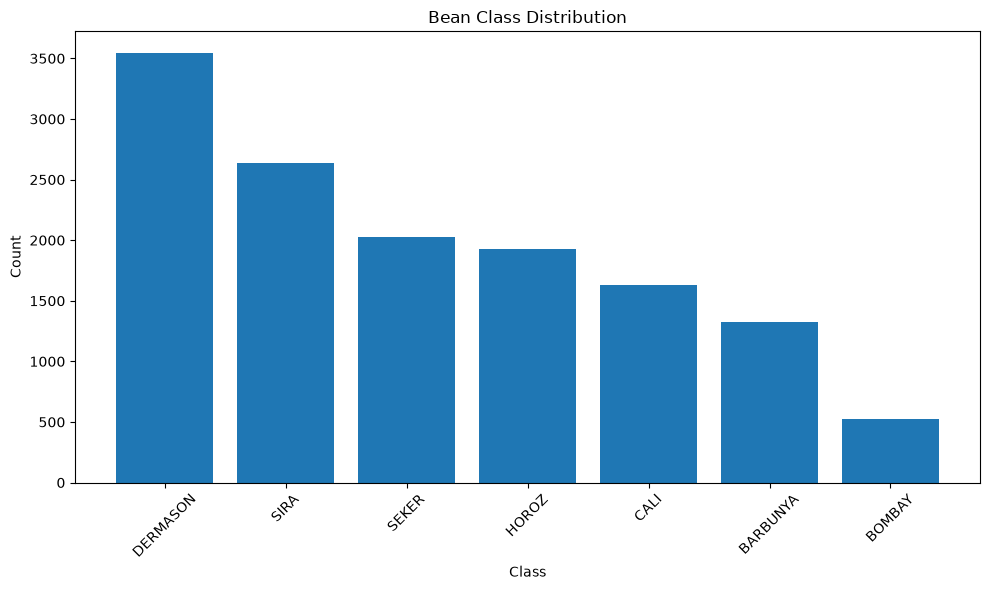

In [5]:
plt.figure(figsize=(10,6))
class_counts = df['Class'].value_counts()
plt.bar(class_counts.index, class_counts.values)
plt.title('Bean Class Distribution')
plt.xlabel('Class')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

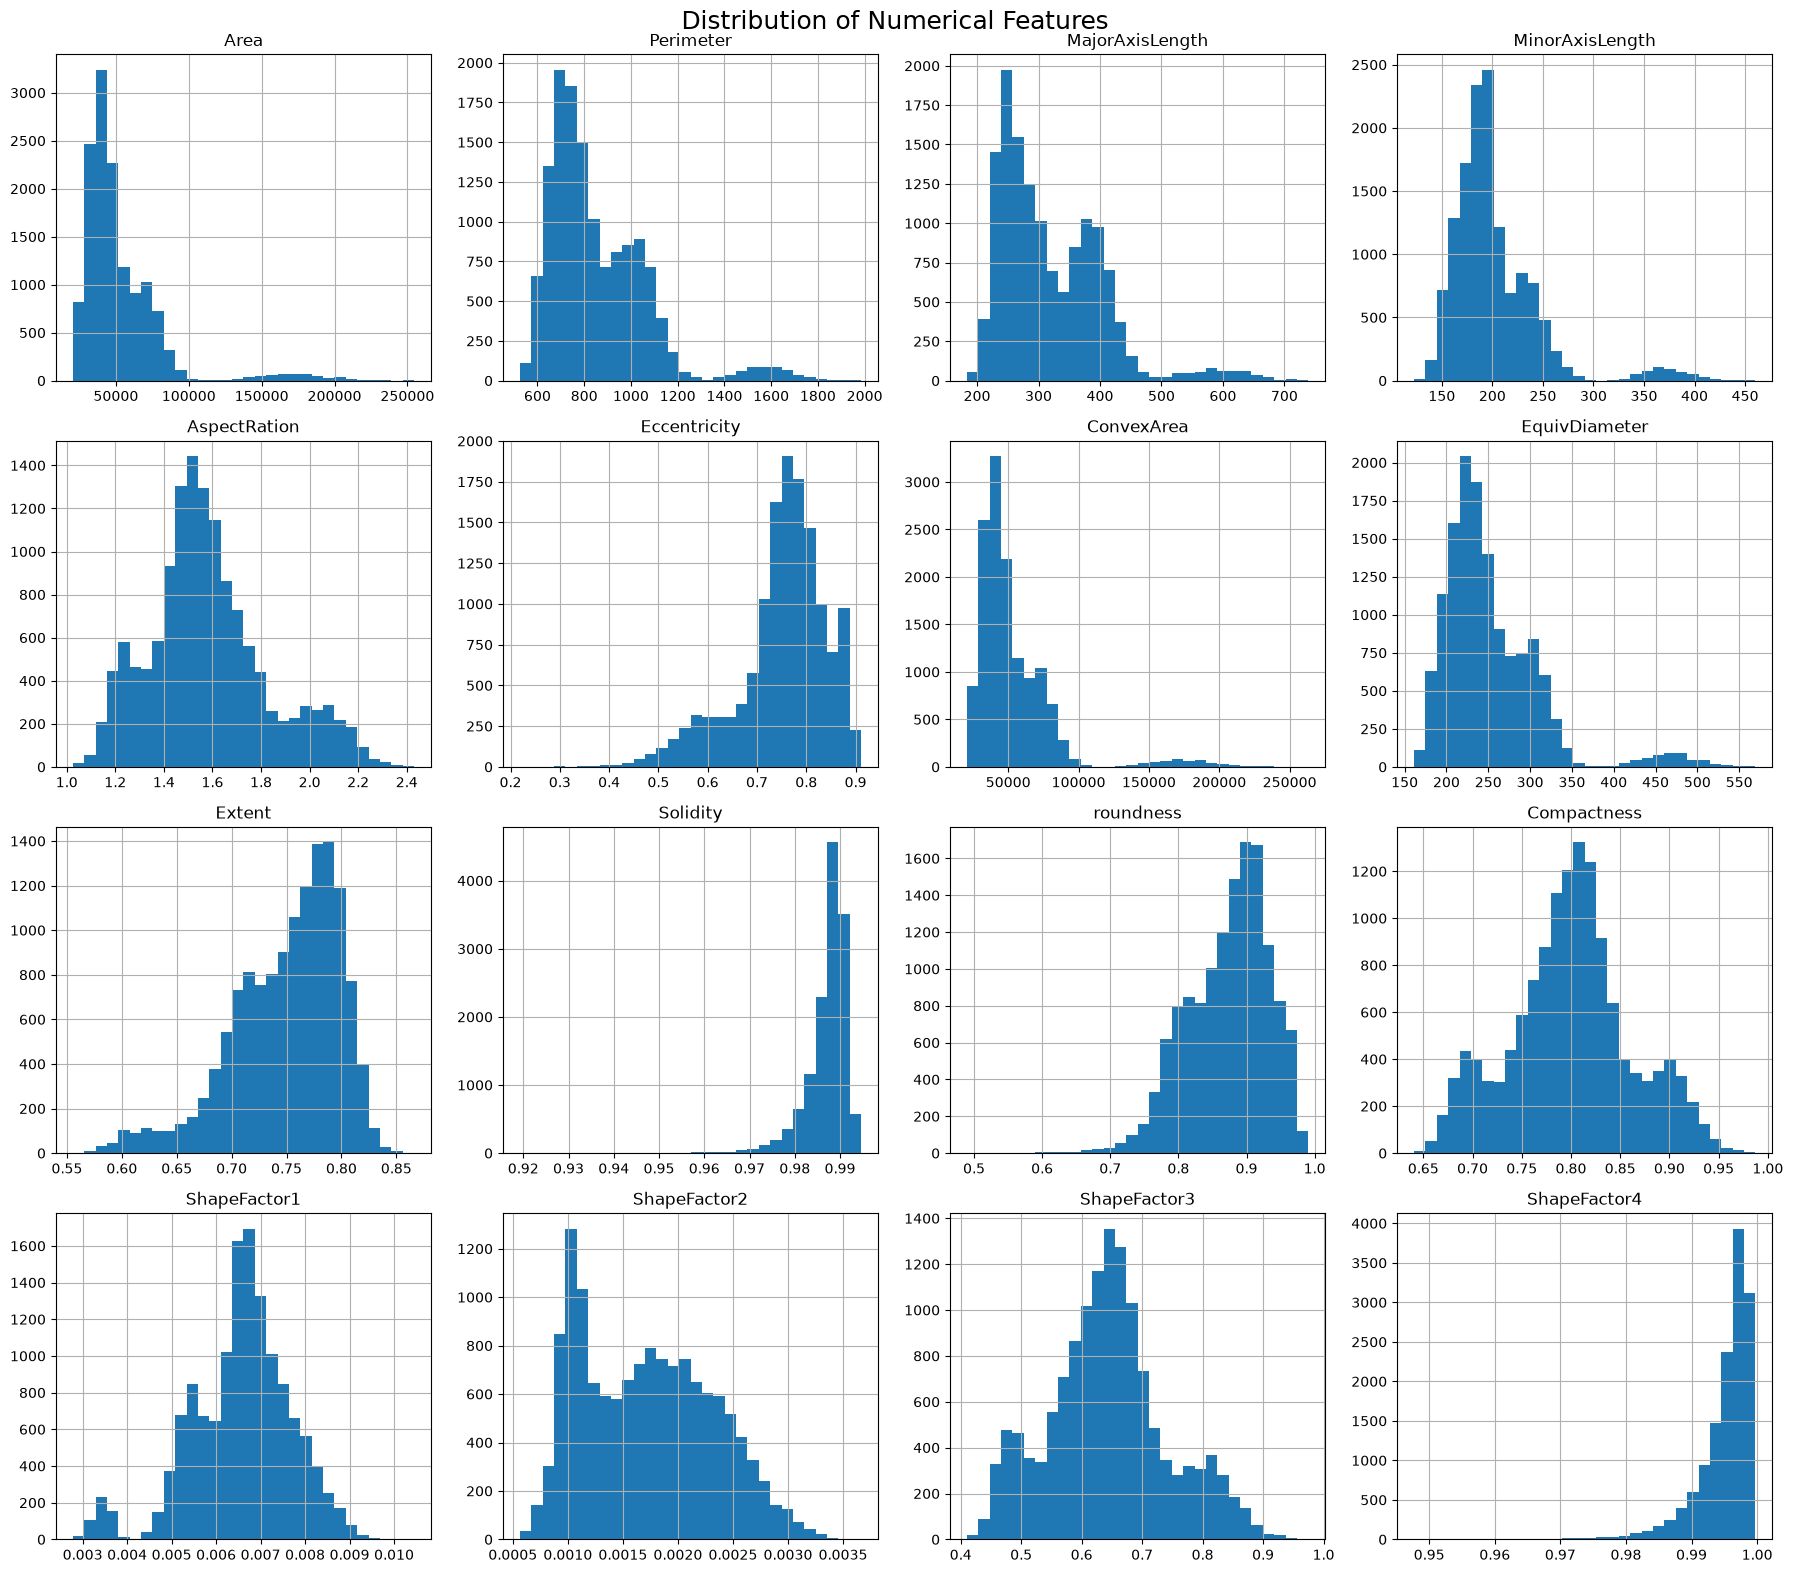

In [6]:
df.hist(figsize=(18,16), bins=30)
plt.suptitle('Distribution of Numerical Features', fontsize=18)
plt.tight_layout()
plt.show()

In [7]:
numerical_cols = ['Area', 'Perimeter', 'MajorAxisLength', 'MinorAxisLength',
       'AspectRation', 'Eccentricity', 'ConvexArea', 'EquivDiameter', 'Extent',
       'Solidity', 'roundness', 'Compactness', 'ShapeFactor1', 'ShapeFactor2',
       'ShapeFactor3', 'ShapeFactor4']

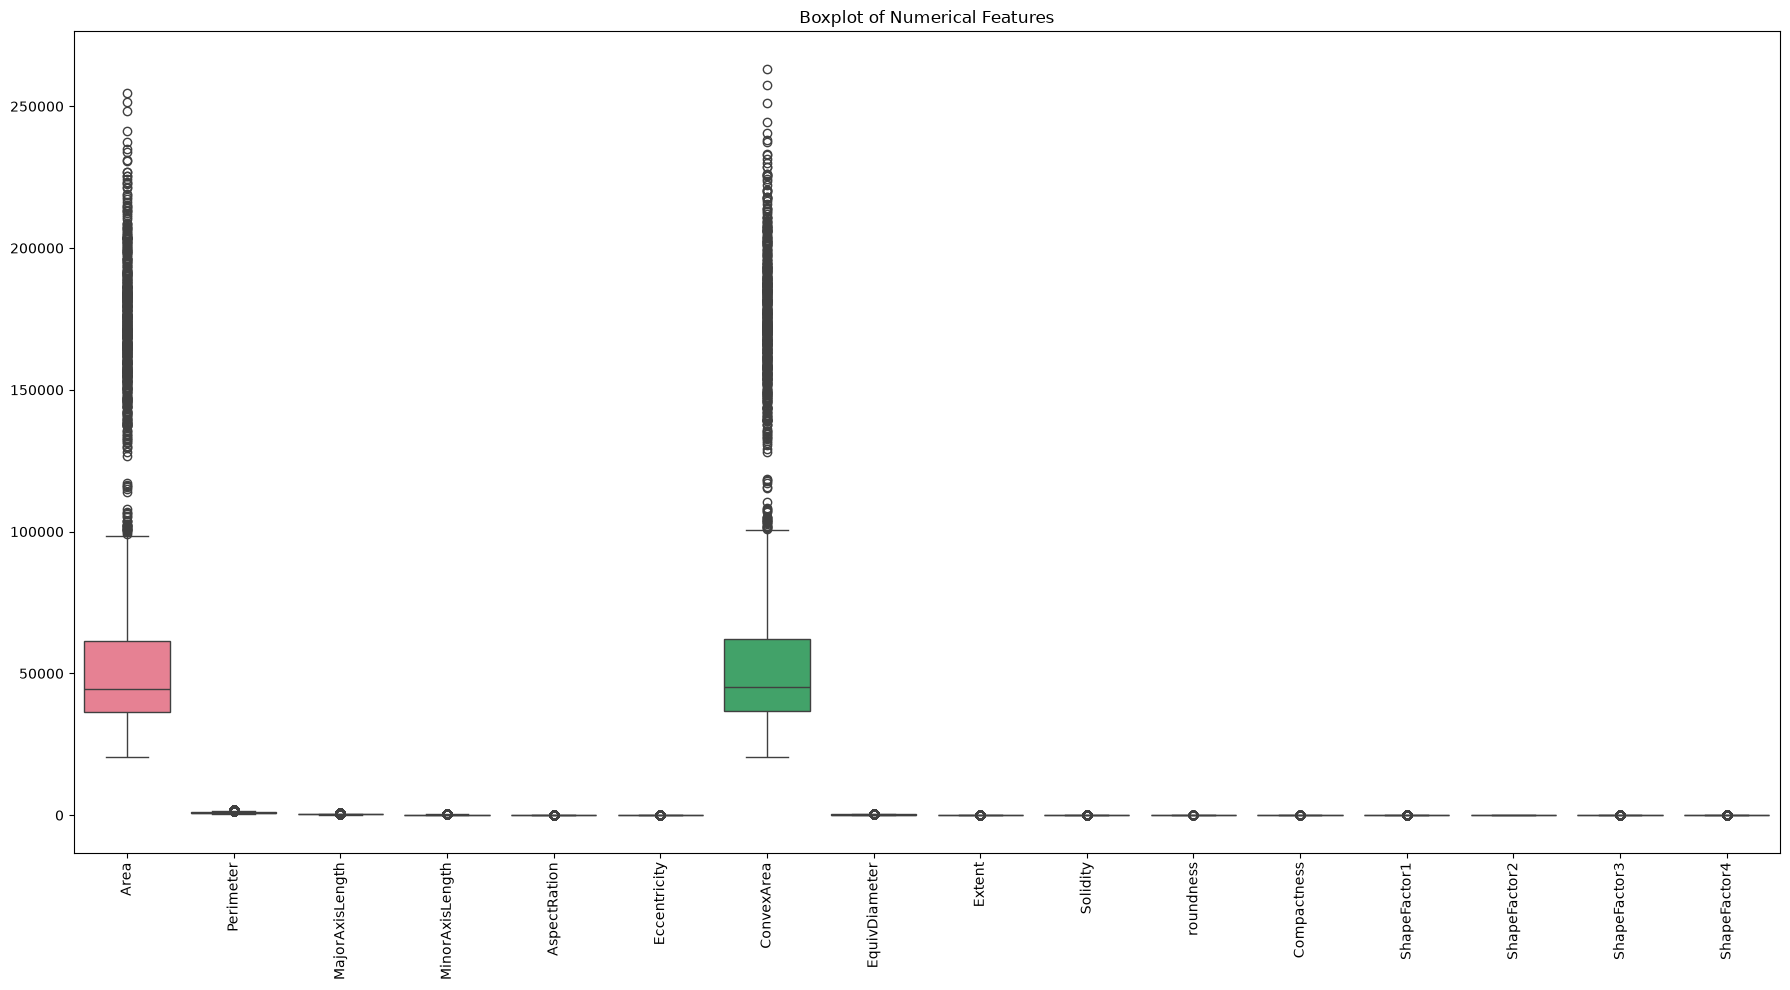

In [8]:
plt.figure(figsize=(18,10))
sns.boxplot(data=df[numerical_cols])
plt.title('Boxplot of Numerical Features')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

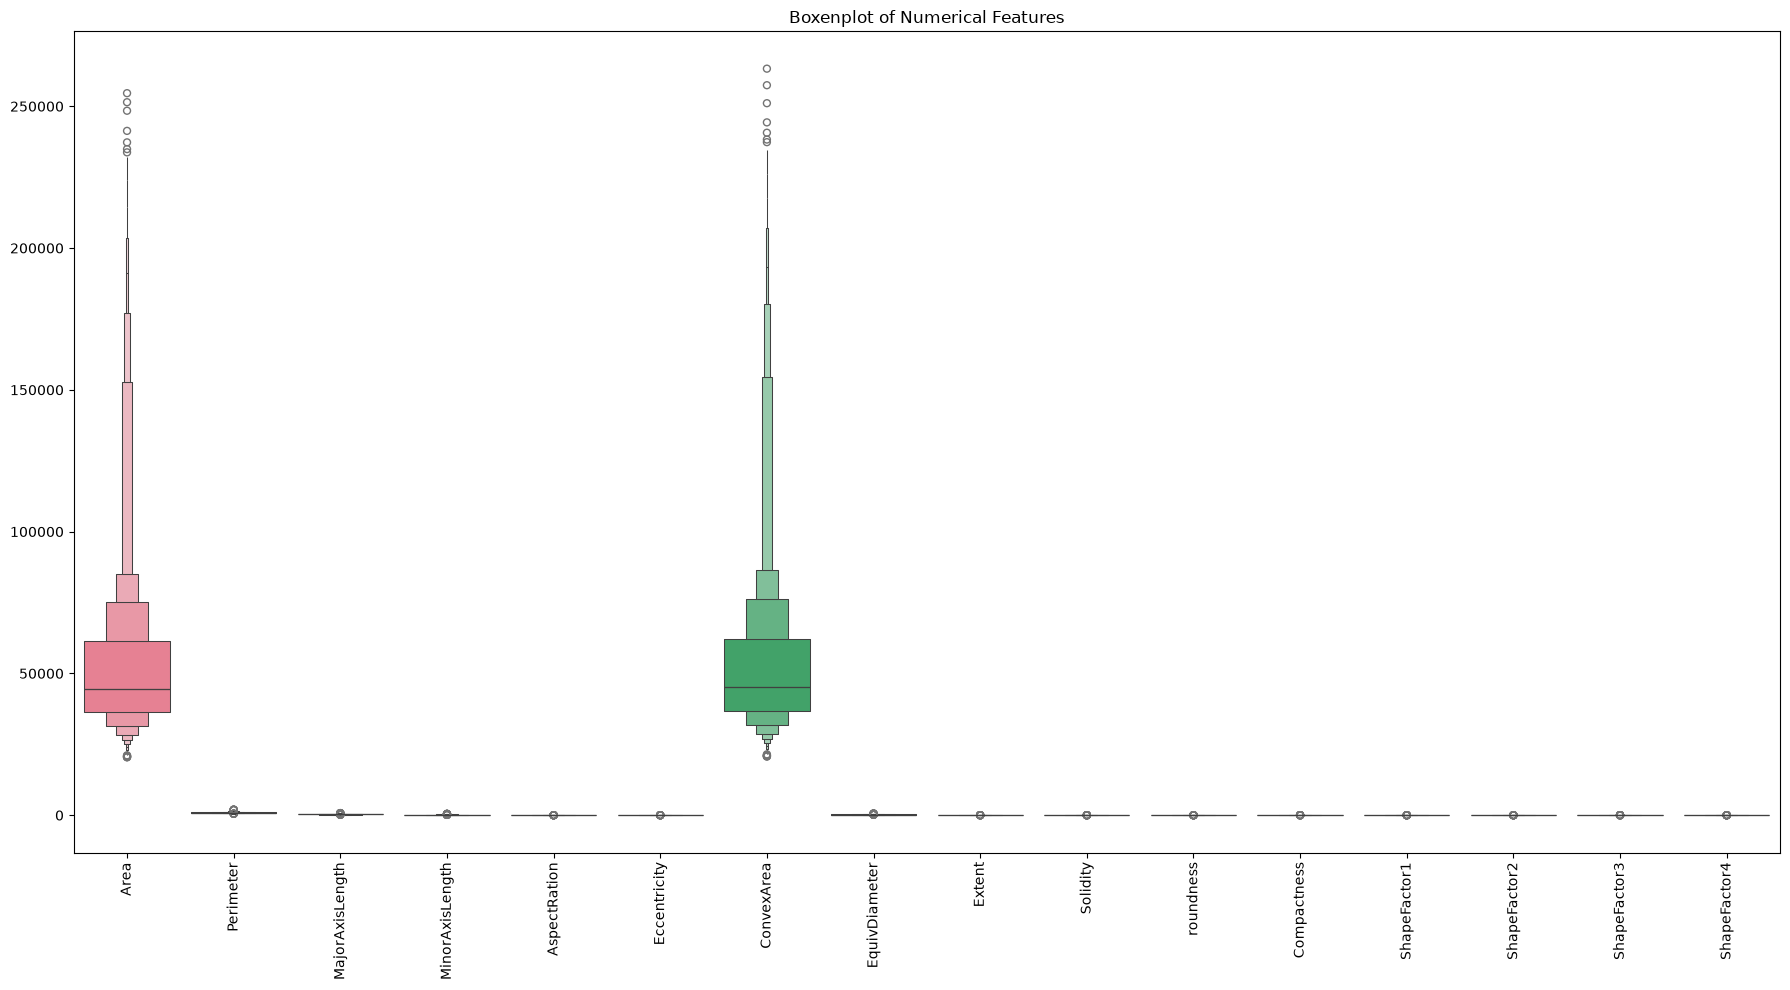

In [9]:
plt.figure(figsize=(18,10))
sns.boxenplot(data=df[numerical_cols])
plt.title('Boxenplot of Numerical Features')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

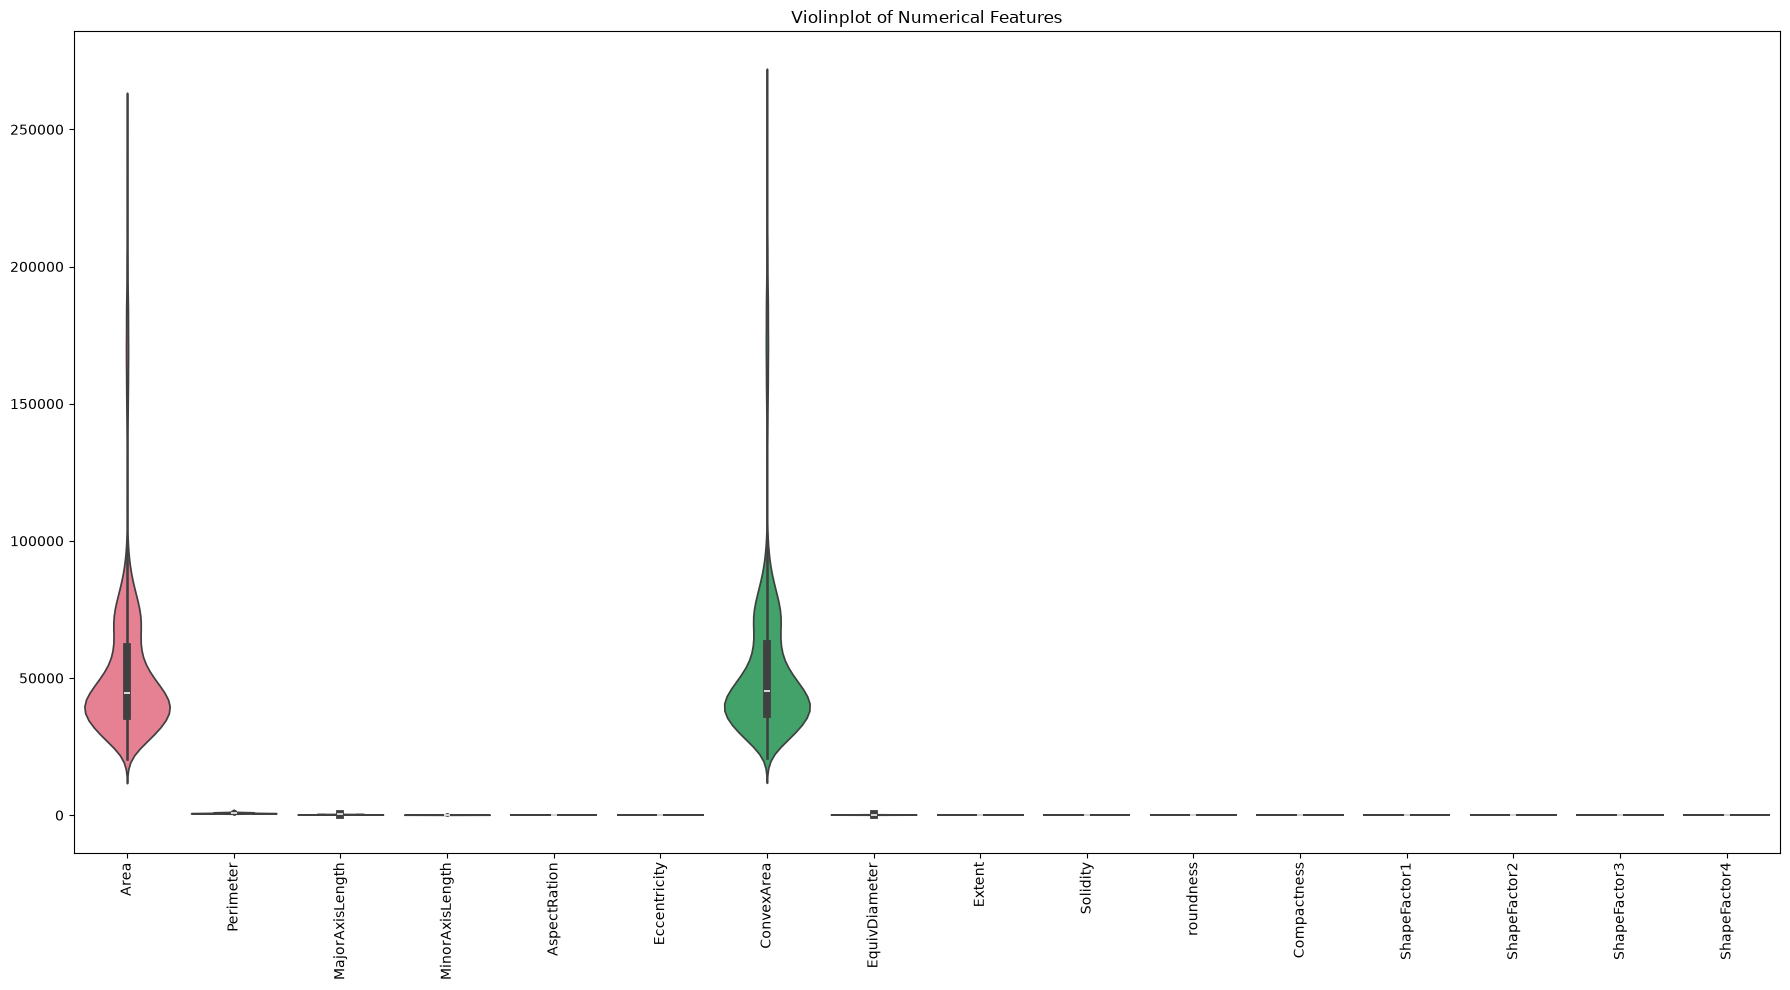

In [10]:
plt.figure(figsize=(18,10))
sns.violinplot(data=df[numerical_cols])
plt.title('Violinplot of Numerical Features')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

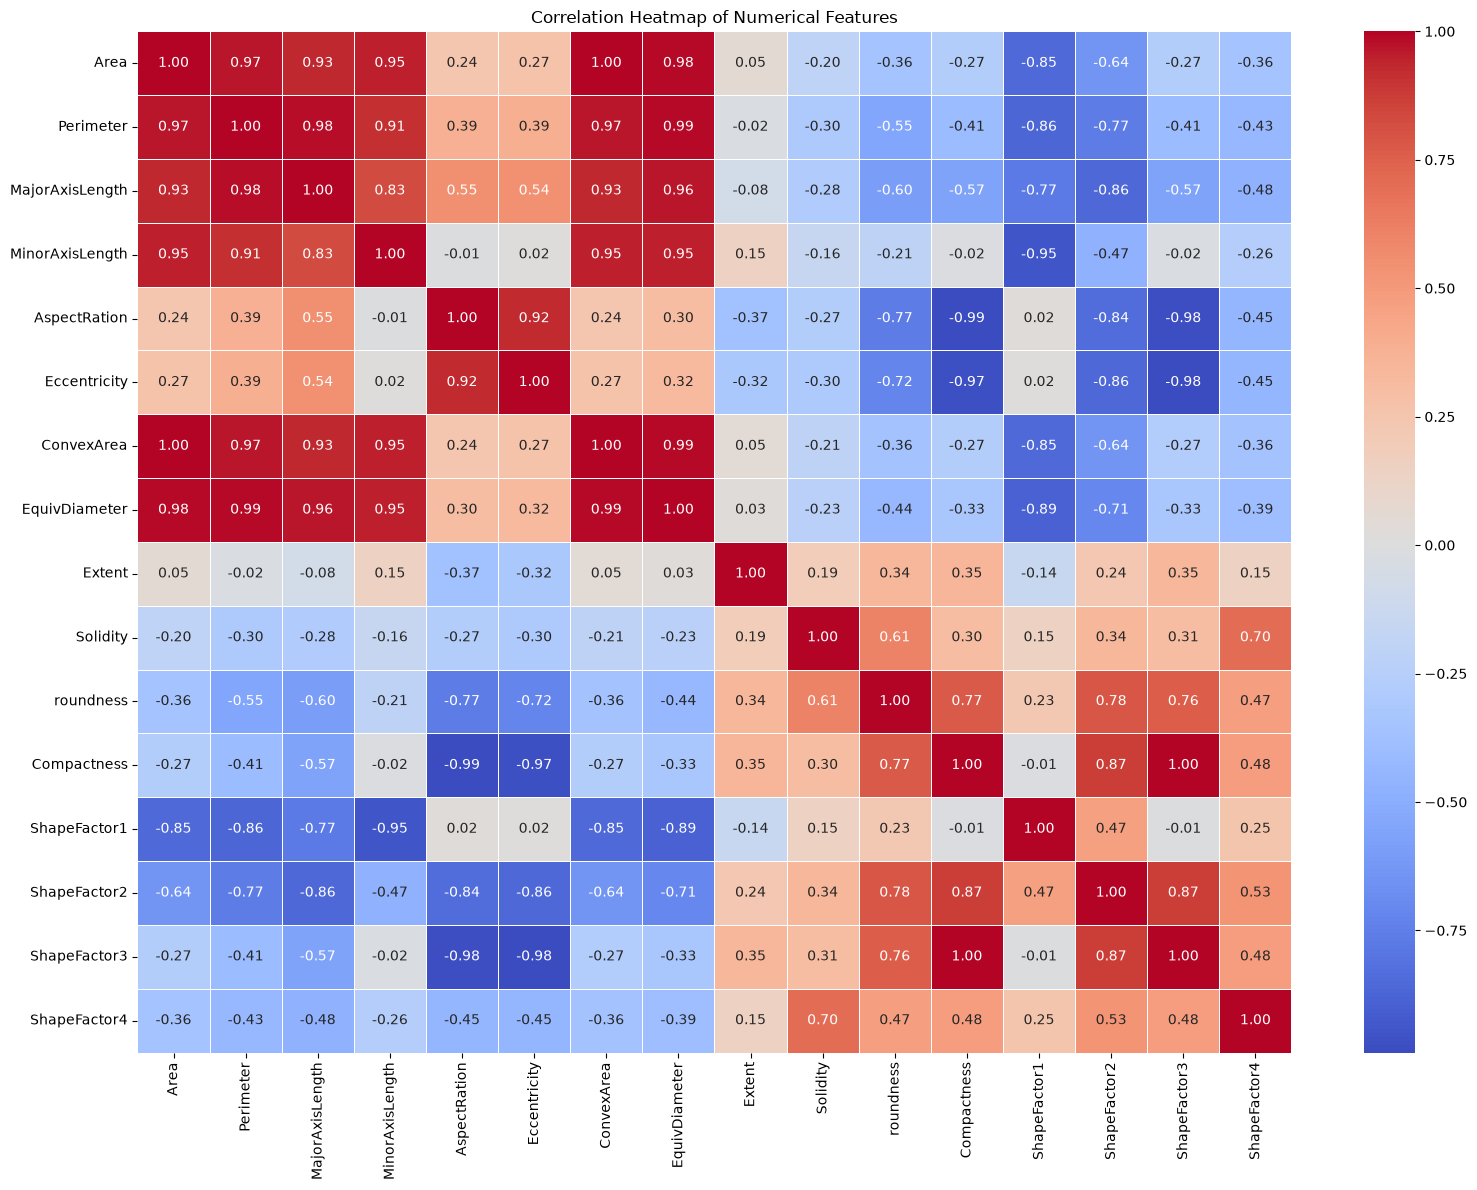

In [11]:
plt.figure(figsize=(16,12))
corr = df[numerical_cols].corr()
sns.heatmap(corr, cmap='coolwarm', annot=True, fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap of Numerical Features')
plt.tight_layout()
plt.show()

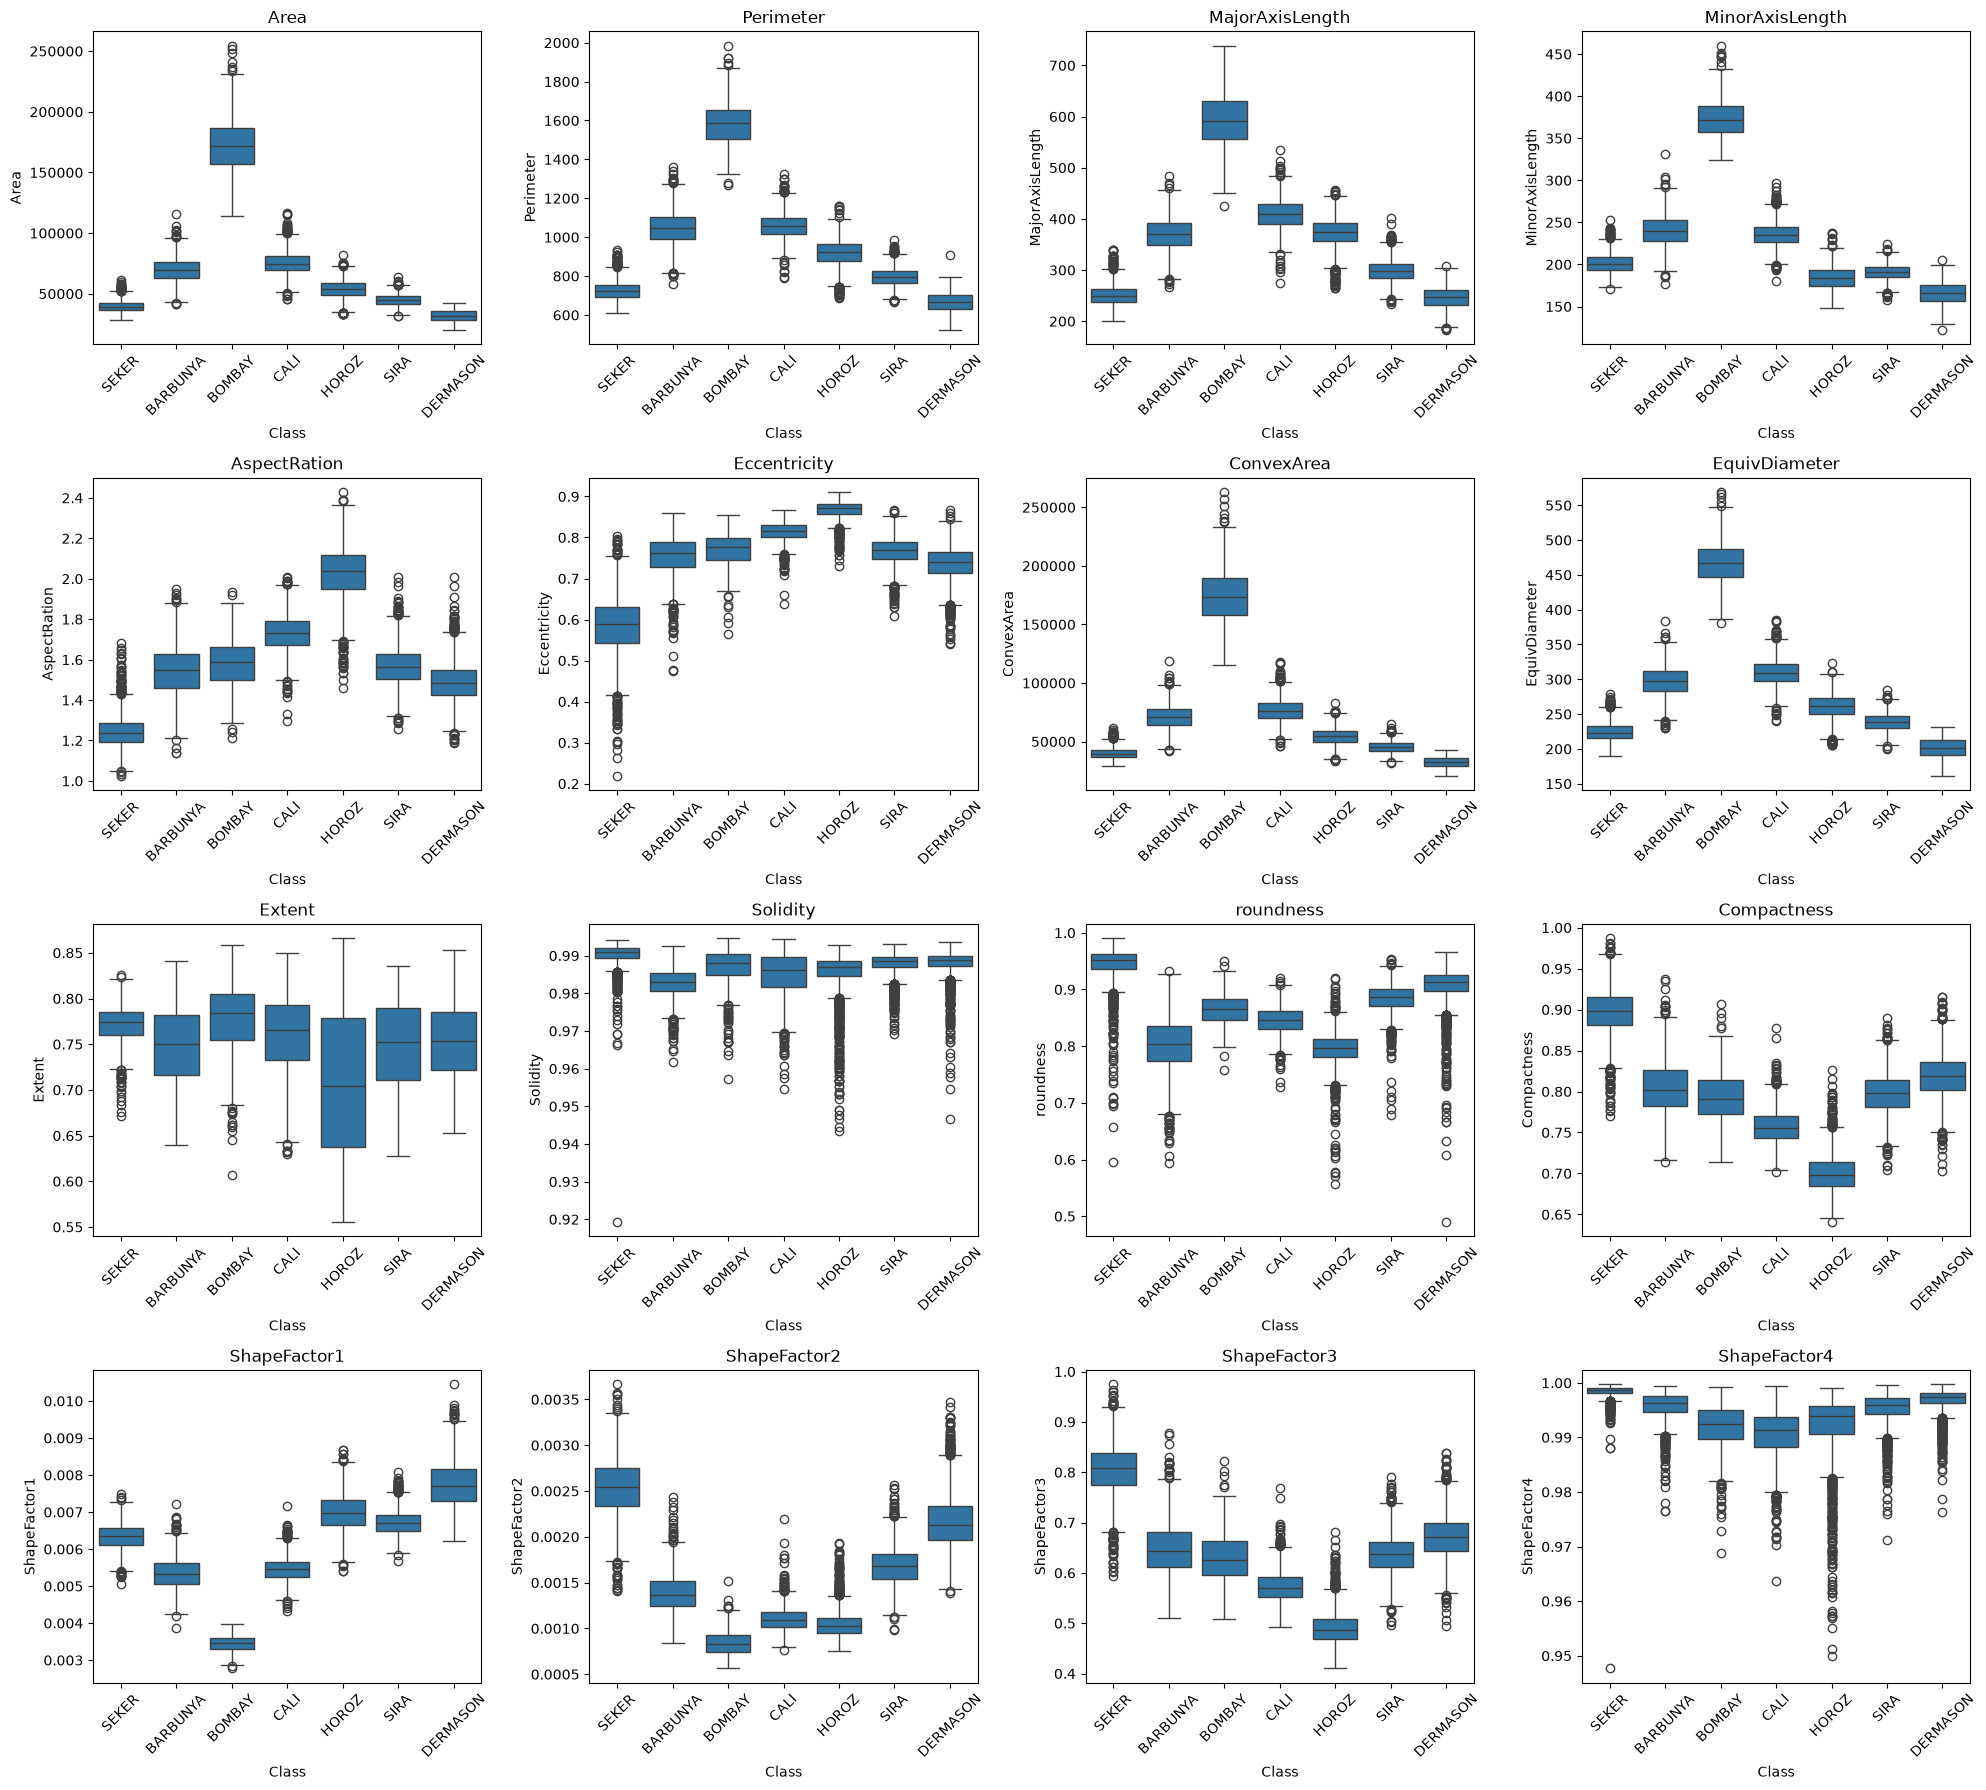

In [12]:
fig, axes = plt.subplots(4, 4, figsize=(20,18))

for i, col in enumerate(numerical_cols):
    sns.boxplot(data=df, x='Class', y=col, ax=axes[i//4, i%4])
    axes[i//4, i%4].tick_params(axis='x', rotation=45)
    axes[i//4, i%4].set_title(col)

plt.tight_layout()
plt.show()

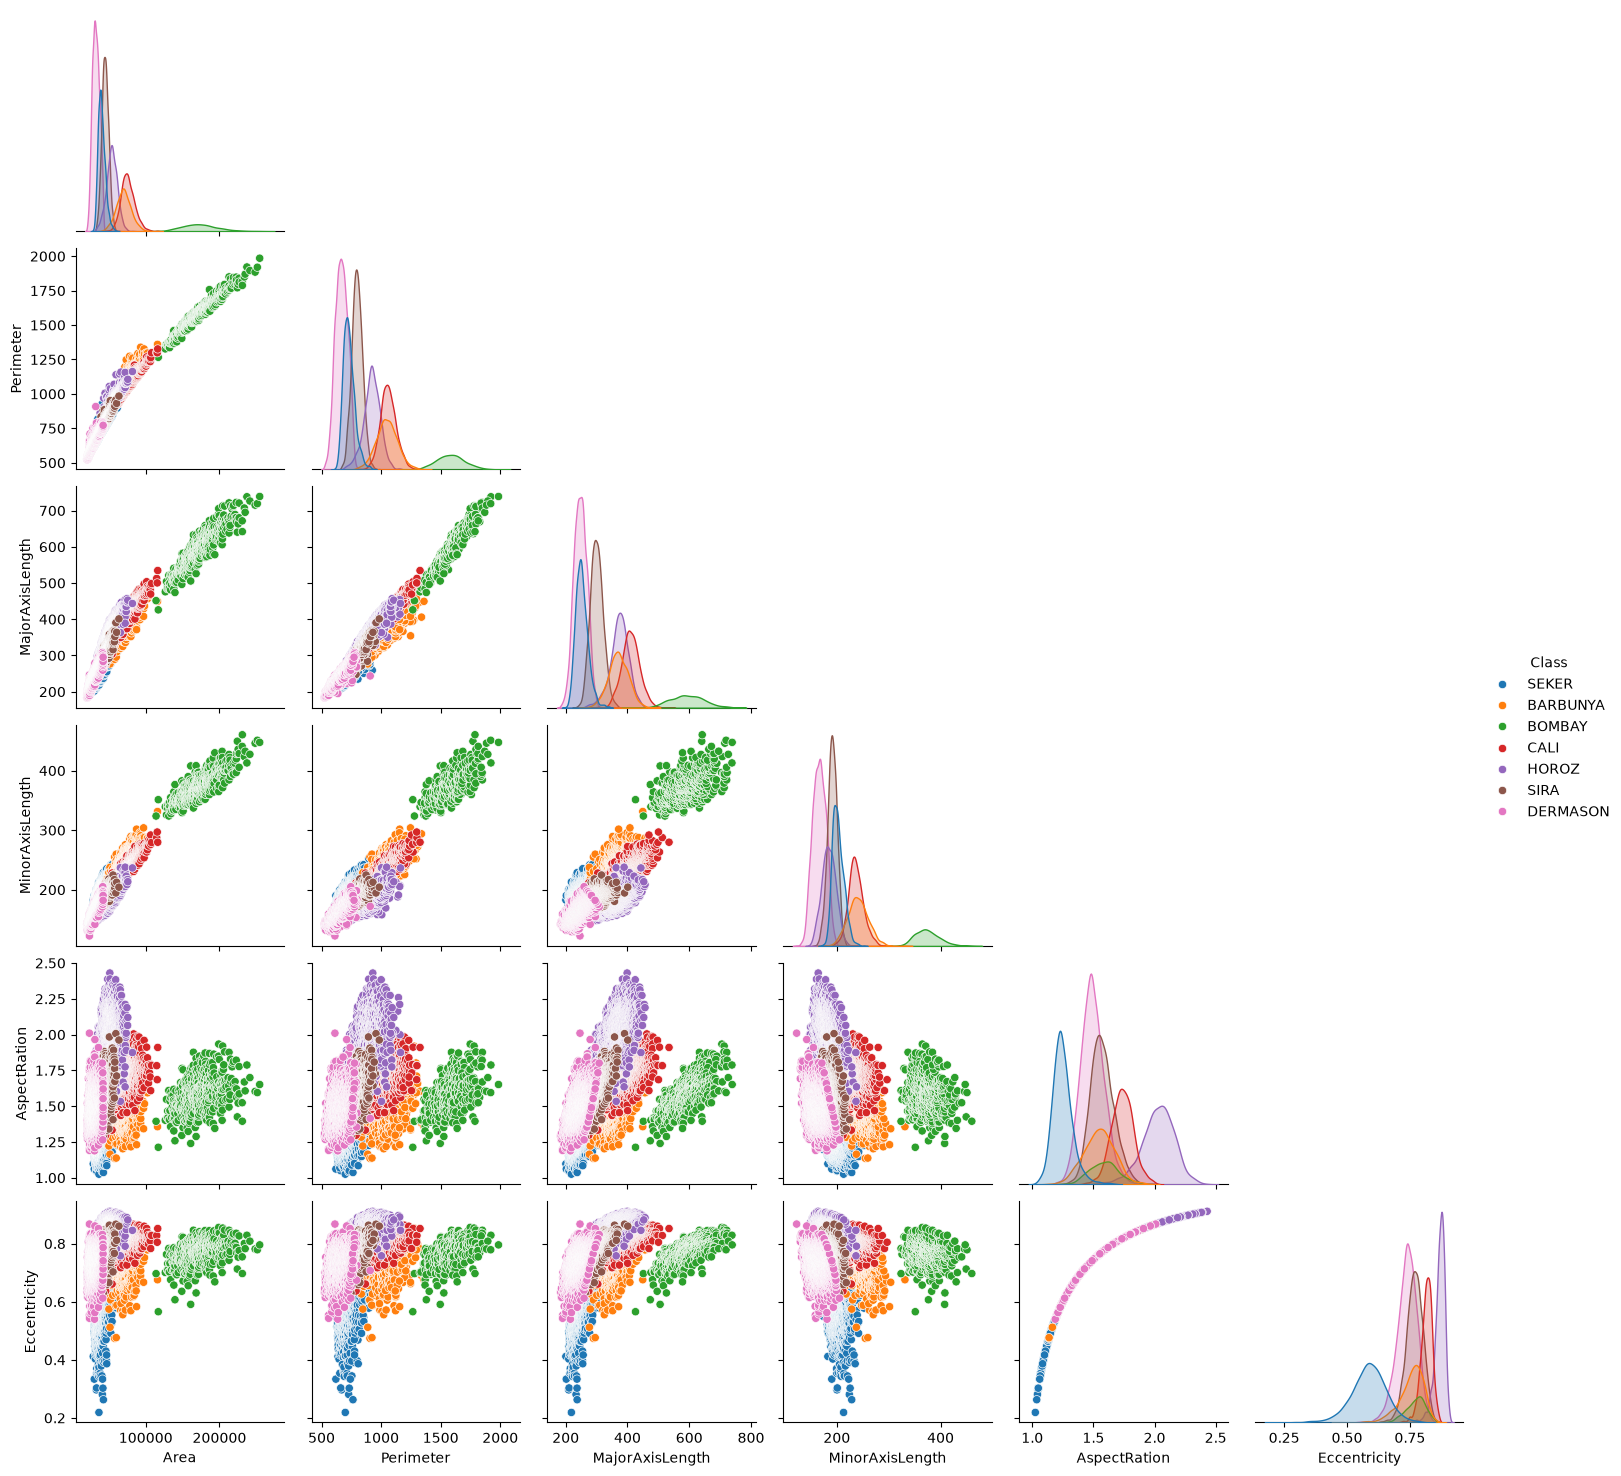

In [13]:


selected_features = [
    'Area',
    'Perimeter',
    'MajorAxisLength',
    'MinorAxisLength',
    'AspectRation',
    'Eccentricity'
]

sns.pairplot(
    df[selected_features + ['Class']],
    hue='Class',
    diag_kind='kde',
    corner=True
)

plt.show()

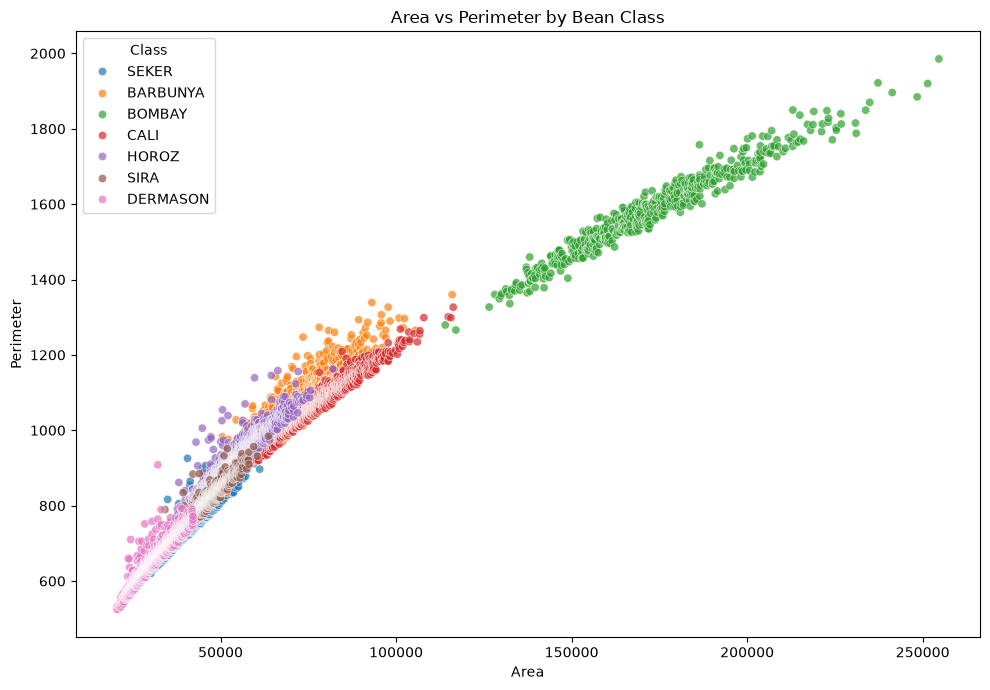

In [14]:
plt.figure(figsize=(10,7))
sns.scatterplot(
    data=df,
    x='Area',
    y='Perimeter',
    hue='Class',
    alpha=0.7
)
plt.title('Area vs Perimeter by Bean Class')
plt.tight_layout()
plt.show()

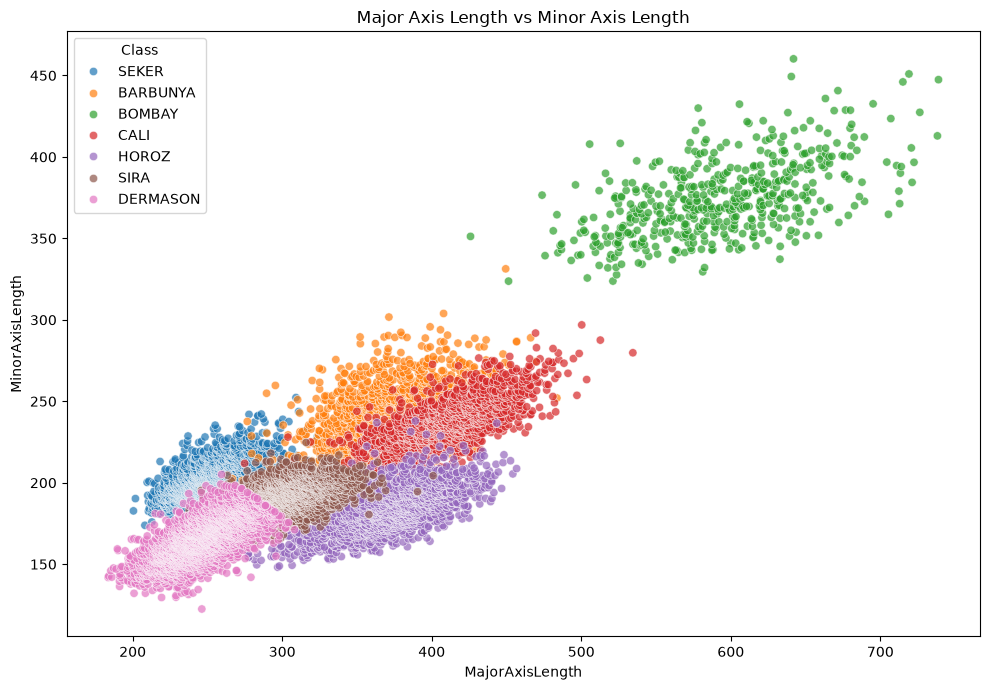

In [15]:
plt.figure(figsize=(10,7))
sns.scatterplot(
    data=df,
    x='MajorAxisLength',
    y='MinorAxisLength',
    hue='Class',
    alpha=0.7
)
plt.title('Major Axis Length vs Minor Axis Length')
plt.tight_layout()
plt.show()

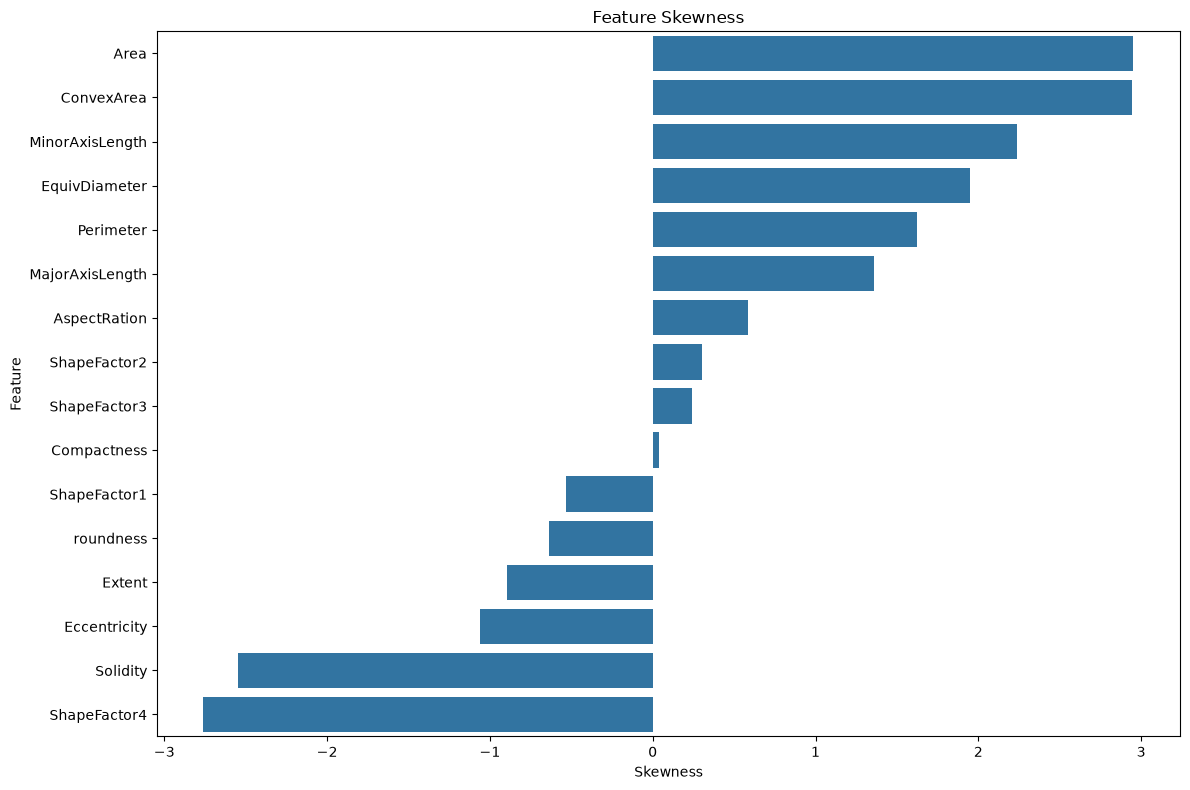

In [16]:
skewness = df[numerical_cols].skew().sort_values(ascending=False)

plt.figure(figsize=(12,8))
sns.barplot(
    x=skewness.values,
    y=skewness.index
)
plt.title('Feature Skewness')
plt.xlabel('Skewness')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

In [17]:
numerical_cols = df.select_dtypes(include=np.number).columns

Q1 = df[numerical_cols].quantile(0.25)
Q3 = df[numerical_cols].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outlier_mask = (
    (df[numerical_cols] < lower_bound) |
    (df[numerical_cols] > upper_bound)
)

outlier_counts = outlier_mask.sum().sort_values(ascending=False)

print(outlier_counts)

Eccentricity       843
Solidity           778
ShapeFactor4       767
MinorAxisLength    569
Area               551
ConvexArea         550
ShapeFactor1       533
EquivDiameter      526
Perimeter          500
AspectRation       473
MajorAxisLength    379
Extent             275
ShapeFactor3       195
Compactness        109
roundness           91
ShapeFactor2         0
dtype: int64


In [18]:
row_outlier_mask = (
    (df[numerical_cols] < lower_bound) |
    (df[numerical_cols] > upper_bound)
).any(axis=1)

df_clean = df.loc[~row_outlier_mask].copy()

print('Original shape:', df.shape)
print('Cleaned shape:', df_clean.shape)
print('Rows removed:', df.shape[0] - df_clean.shape[0])

Original shape: (13611, 17)
Cleaned shape: (10594, 17)
Rows removed: 3017


In [19]:
Q1_clean = df_clean[numerical_cols].quantile(0.25)
Q3_clean = df_clean[numerical_cols].quantile(0.75)
IQR_clean = Q3_clean - Q1_clean

lower_clean = Q1_clean - 1.5 * IQR_clean
upper_clean = Q3_clean + 1.5 * IQR_clean

remaining_outliers = (
    (df_clean[numerical_cols] < lower_clean) |
    (df_clean[numerical_cols] > upper_clean)
).sum()

print(remaining_outliers.sort_values(ascending=False))

AspectRation       463
Eccentricity       352
ShapeFactor4       314
Solidity           258
MinorAxisLength    228
ConvexArea         193
Area               188
roundness           69
EquivDiameter       23
Extent              13
ShapeFactor1         5
Perimeter            1
MajorAxisLength      0
Compactness          0
ShapeFactor2         0
ShapeFactor3         0
dtype: int64


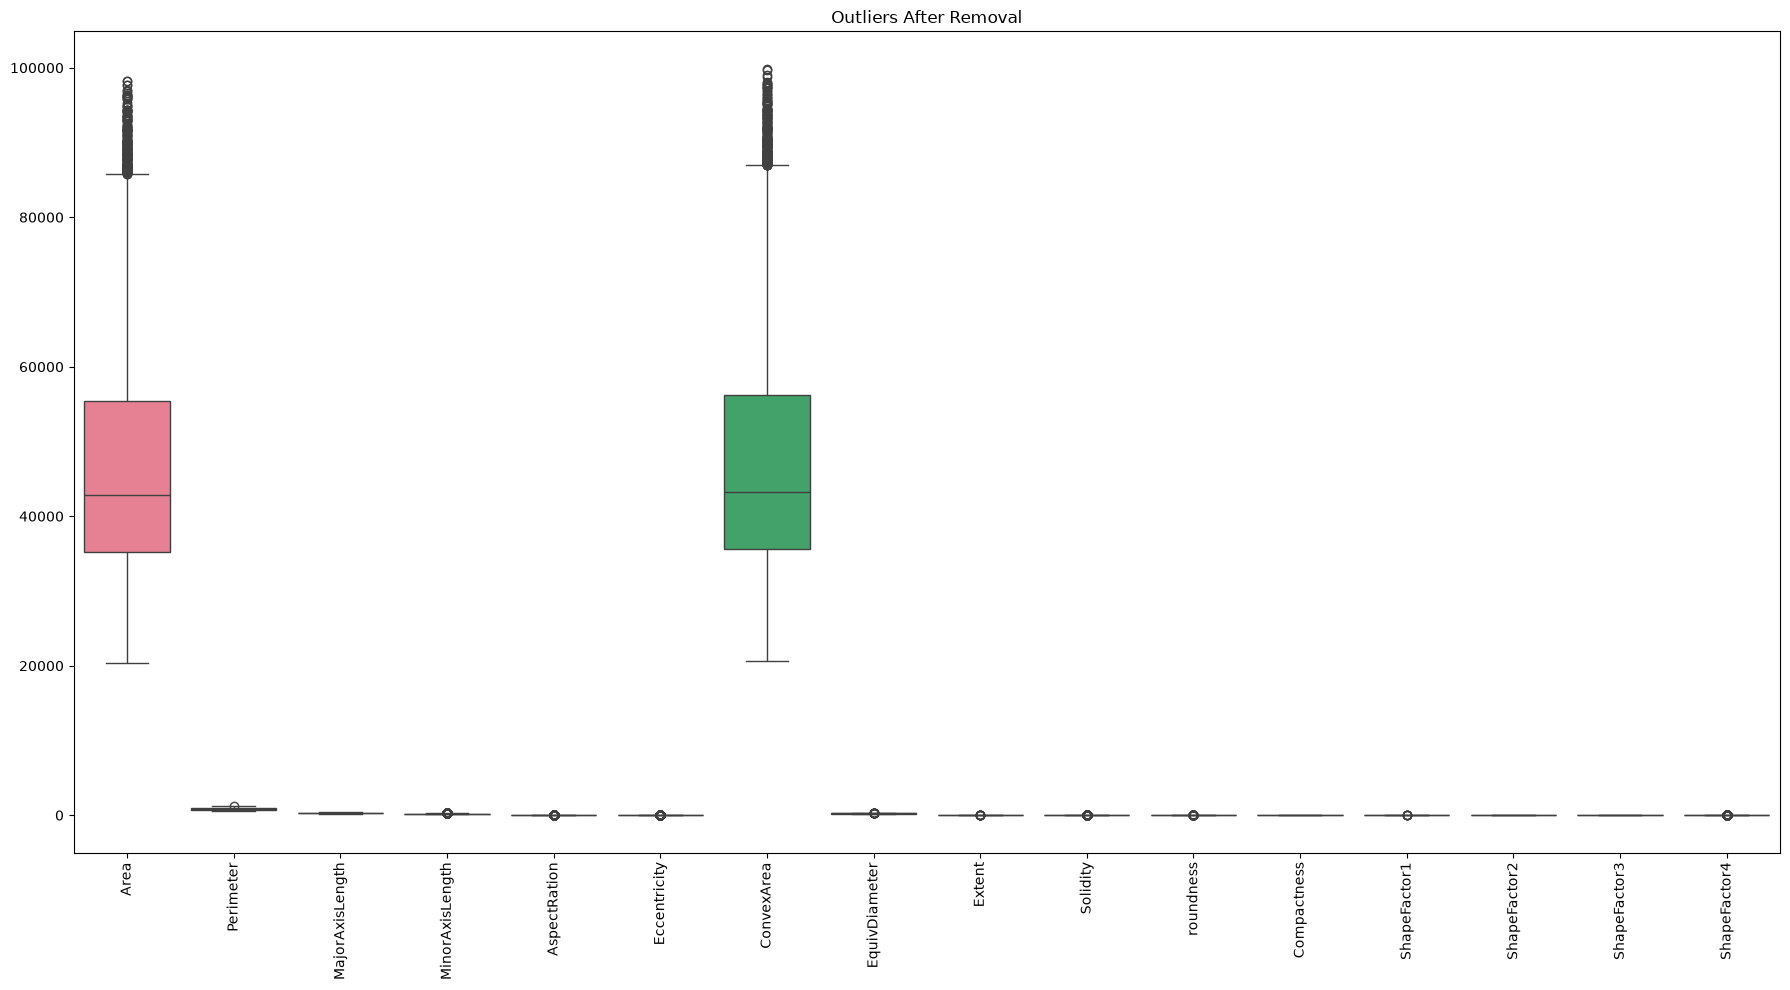

In [20]:
plt.figure(figsize=(18, 10))
sns.boxplot(data=df_clean[numerical_cols])
plt.title('Outliers After Removal')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

Class
DERMASON    3463
SIRA        2582
CALI        1225
SEKER       1187
BARBUNYA    1071
HOROZ       1066
Name: count, dtype: int64


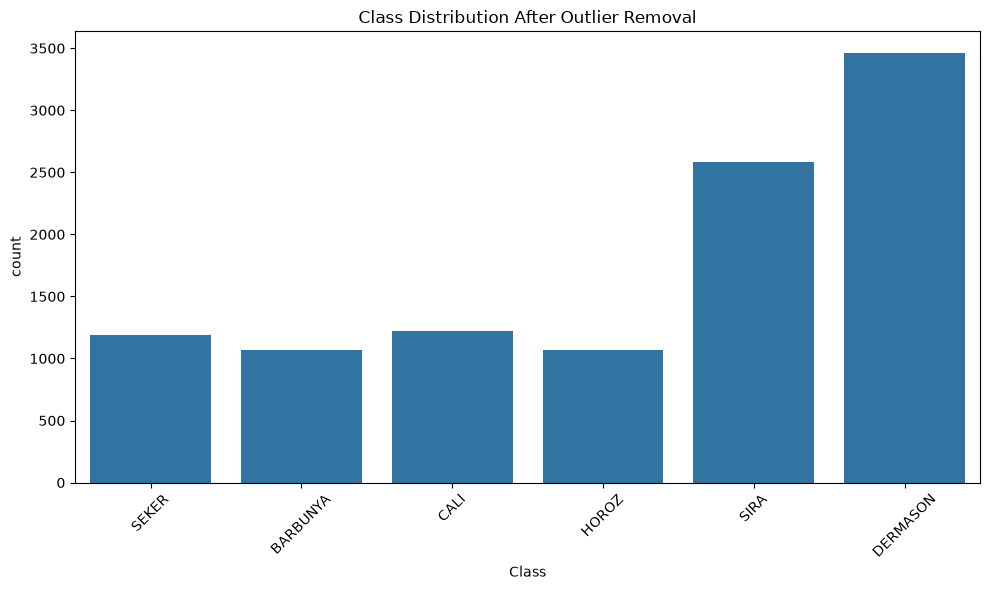

In [21]:
print(df_clean['Class'].value_counts())

plt.figure(figsize=(10, 6))
sns.countplot(data=df_clean, x='Class')
plt.title('Class Distribution After Outlier Removal')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [22]:
df = df_clean.copy()

In [23]:
from sklearn.preprocessing import LabelEncoder
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

le = LabelEncoder()

df_corr = df.copy()
df_corr['Class_encoded'] = le.fit_transform(df_corr['Class'])

numerical_cols = df.select_dtypes(include=np.number).columns.tolist()

feature_target_corr = (
    df_corr[numerical_cols]
    .corrwith(df_corr['Class_encoded'])
    .abs()
    .sort_values(ascending=False)
)

print(feature_target_corr)

ConvexArea         0.384651
Area               0.382267
Perimeter          0.360316
roundness          0.334579
EquivDiameter      0.334289
Solidity           0.321275
MinorAxisLength    0.317329
MajorAxisLength    0.312212
ShapeFactor1       0.210656
ShapeFactor2       0.191633
Eccentricity       0.140954
ShapeFactor3       0.126509
Compactness        0.121808
ShapeFactor4       0.108547
AspectRation       0.105480
Extent             0.025691
dtype: float64


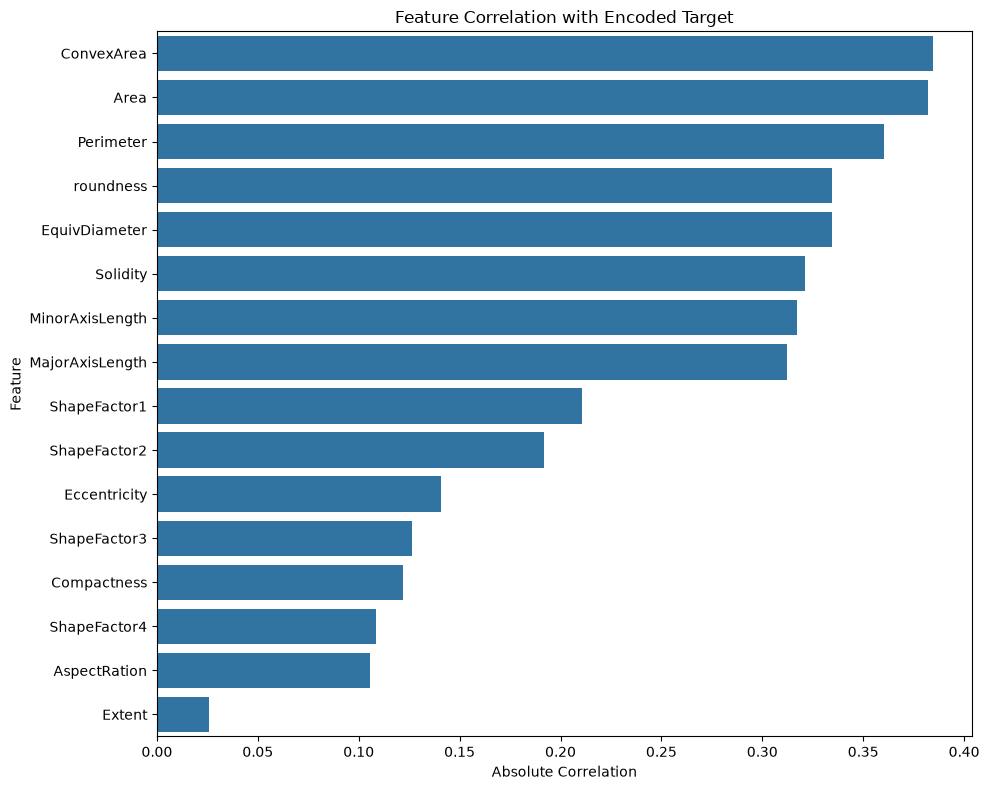

In [24]:
plt.figure(figsize=(10,8))

sns.barplot(
    x=feature_target_corr.values,
    y=feature_target_corr.index
)

plt.title('Feature Correlation with Encoded Target')
plt.xlabel('Absolute Correlation')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

In [25]:
corr_matrix = df[numerical_cols].corr().abs()

upper = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

high_corr_pairs = (
    upper
    .stack()
    .reset_index()
)

high_corr_pairs.columns = ['Feature_1', 'Feature_2', 'Correlation']

high_corr_pairs = high_corr_pairs[
    high_corr_pairs['Correlation'] >= 0.90
].sort_values('Correlation', ascending=False)

print(high_corr_pairs)

           Feature_1        Feature_2  Correlation
6               Area       ConvexArea     0.999952
190      Compactness     ShapeFactor3     0.999156
7               Area    EquivDiameter     0.996260
103       ConvexArea    EquivDiameter     0.996111
75      AspectRation      Compactness     0.992110
23         Perimeter    EquivDiameter     0.992050
94      Eccentricity     ShapeFactor3     0.990000
22         Perimeter       ConvexArea     0.989284
1               Area        Perimeter     0.988746
78      AspectRation     ShapeFactor3     0.986215
60   MinorAxisLength     ShapeFactor1     0.984437
91      Eccentricity      Compactness     0.983506
18         Perimeter  MajorAxisLength     0.972717
39   MajorAxisLength    EquivDiameter     0.959650
2               Area  MajorAxisLength     0.955154
38   MajorAxisLength       ConvexArea     0.955063
69      AspectRation     Eccentricity     0.954424
45   MajorAxisLength     ShapeFactor2     0.930141
55   MinorAxisLength    EquivDi

In [26]:
from sklearn.feature_selection import f_classif

X = df[numerical_cols]
y = df['Class']

f_scores, p_values = f_classif(X, y)

feature_scores = pd.DataFrame({
    'Feature': numerical_cols,
    'F_Score': f_scores,
    'P_Value': p_values
}).sort_values('F_Score', ascending=False)

print(feature_scores)

            Feature       F_Score        P_Value
1         Perimeter  13493.040760   0.000000e+00
2   MajorAxisLength  12587.712078   0.000000e+00
6        ConvexArea  12369.587814   0.000000e+00
0              Area  12250.568407   0.000000e+00
7     EquivDiameter  12217.359666   0.000000e+00
3   MinorAxisLength   9327.532359   0.000000e+00
13     ShapeFactor2   8344.239051   0.000000e+00
12     ShapeFactor1   7589.540739   0.000000e+00
4      AspectRation   7119.958051   0.000000e+00
11      Compactness   6572.447370   0.000000e+00
14     ShapeFactor3   6373.729206   0.000000e+00
10        roundness   6143.995281   0.000000e+00
5      Eccentricity   5763.687135   0.000000e+00
15     ShapeFactor4   1507.794703   0.000000e+00
9          Solidity    894.590896   0.000000e+00
8            Extent    151.762702  3.666425e-156


In [27]:
selected_features = feature_scores[
    feature_scores['P_Value'] < 0.05
]['Feature'].tolist()

selected_corr = df[selected_features].corr().abs()

upper = selected_corr.where(
    np.triu(np.ones(selected_corr.shape), k=1).astype(bool)
)

to_remove = [
    column
    for column in upper.columns
    if any(upper[column] > 0.90)
]

final_features = [
    feature for feature in selected_features
    if feature not in to_remove
]

print('Selected features:')
print(selected_features)

print('\nRemoved redundant features:')
print(to_remove)

print('\nFinal features:')
print(final_features)

Selected features:
['Perimeter', 'MajorAxisLength', 'ConvexArea', 'Area', 'EquivDiameter', 'MinorAxisLength', 'ShapeFactor2', 'ShapeFactor1', 'AspectRation', 'Compactness', 'ShapeFactor3', 'roundness', 'Eccentricity', 'ShapeFactor4', 'Solidity', 'Extent']

Removed redundant features:
['MajorAxisLength', 'ConvexArea', 'Area', 'EquivDiameter', 'MinorAxisLength', 'ShapeFactor2', 'ShapeFactor1', 'Compactness', 'ShapeFactor3', 'Eccentricity']

Final features:
['Perimeter', 'AspectRation', 'roundness', 'ShapeFactor4', 'Solidity', 'Extent']


In [28]:
print('Number of original features:', len(numerical_cols))
print('Number of selected features:', len(selected_features))
print('Number of final features:', len(final_features))

print('\nFinal feature list:')
for feature in final_features:
    print(feature)

Number of original features: 16
Number of selected features: 16
Number of final features: 6

Final feature list:
Perimeter
AspectRation
roundness
ShapeFactor4
Solidity
Extent


In [29]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

from imblearn.over_sampling import SMOTE

features = [
    'Perimeter',
    'AspectRation',
    'roundness',
    'ShapeFactor4',
    'Solidity',
    'Extent'
]

X = df[features]
y = df['Class']

le = LabelEncoder()
y = le.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train_scaled,
    y_train
)

print("Original training data:", X_train.shape)
print("After SMOTE:", X_train_smote.shape)

k_values = range(1, 21)

accuracy = []
precision = []
recall = []
f1 = []

for k in k_values:

    model = KNeighborsClassifier(n_neighbors=k)

    model.fit(X_train_smote, y_train_smote)

    y_pred = model.predict(X_test_scaled)

    accuracy.append(accuracy_score(y_test, y_pred))
    precision.append(precision_score(y_test, y_pred, average='weighted'))
    recall.append(recall_score(y_test, y_pred, average='weighted'))
    f1.append(f1_score(y_test, y_pred, average='weighted'))

best_k = k_values[np.argmax(f1)]

print("Best K:", best_k)

model = KNeighborsClassifier(n_neighbors=best_k)

model.fit(X_train_smote, y_train_smote)

y_pred = model.predict(X_test_scaled)

acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, average='weighted')
rec = recall_score(y_test, y_pred, average='weighted')
f1_score_value = f1_score(y_test, y_pred, average='weighted')

print("\nFinal Results")
print("Accuracy :", acc)
print("Precision:", prec)
print("Recall   :", rec)
print("F1 Score :", f1_score_value)

print("\nClassification Report")
print(classification_report(
    y_test,
    y_pred,
    target_names=le.classes_
))

Original training data: (8475, 6)
After SMOTE: (16620, 6)
Best K: 12

Final Results
Accuracy : 0.9023124115148655
Precision: 0.9030446066470541
Recall   : 0.9023124115148655
F1 Score : 0.9023537874657193

Classification Report
              precision    recall  f1-score   support

    BARBUNYA       0.91      0.93      0.92       214
        CALI       0.93      0.91      0.92       245
    DERMASON       0.93      0.89      0.91       693
       HOROZ       0.93      0.96      0.94       213
       SEKER       0.86      0.93      0.90       237
        SIRA       0.86      0.86      0.86       517

    accuracy                           0.90      2119
   macro avg       0.90      0.91      0.91      2119
weighted avg       0.90      0.90      0.90      2119



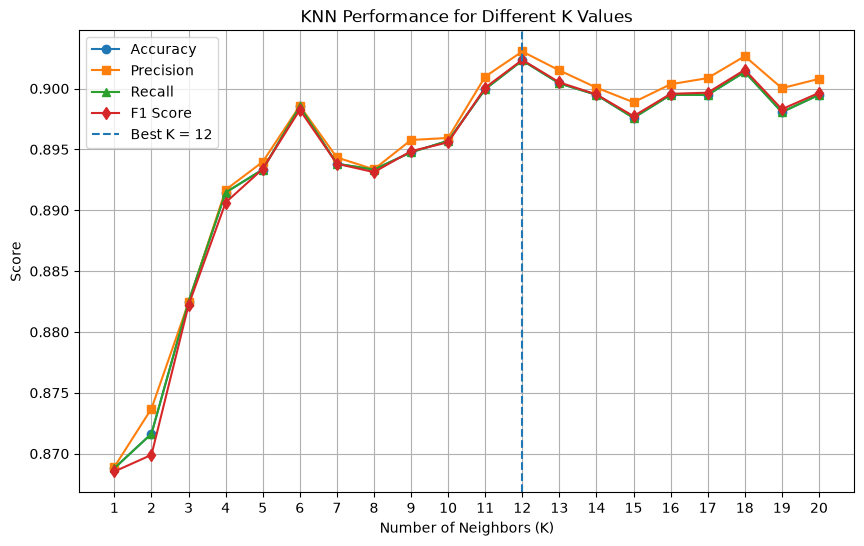

In [30]:
plt.figure(figsize=(10,6))

plt.plot(k_values, accuracy, marker='o', label='Accuracy')
plt.plot(k_values, precision, marker='s', label='Precision')
plt.plot(k_values, recall, marker='^', label='Recall')
plt.plot(k_values, f1, marker='d', label='F1 Score')

plt.axvline(best_k, linestyle='--', label=f'Best K = {best_k}')

plt.xlabel('Number of Neighbors (K)')
plt.ylabel('Score')
plt.title('KNN Performance for Different K Values')
plt.xticks(k_values)
plt.legend()
plt.grid()
plt.show()

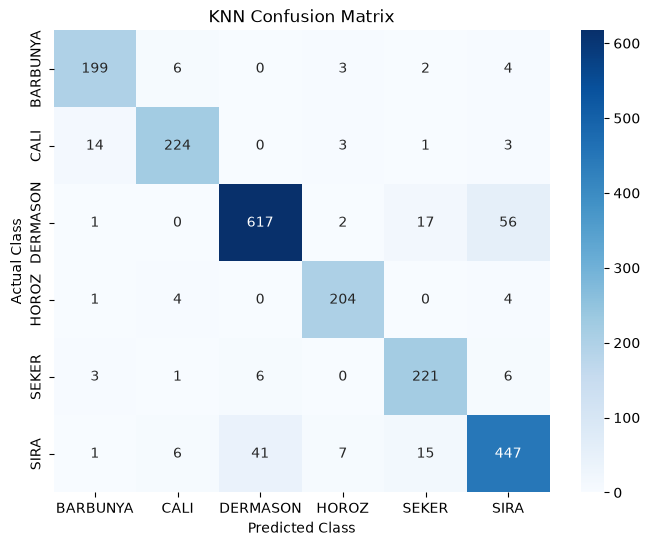

In [31]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=le.classes_,
    yticklabels=le.classes_
)

plt.xlabel('Predicted Class')
plt.ylabel('Actual Class')
plt.title('KNN Confusion Matrix')

plt.show()

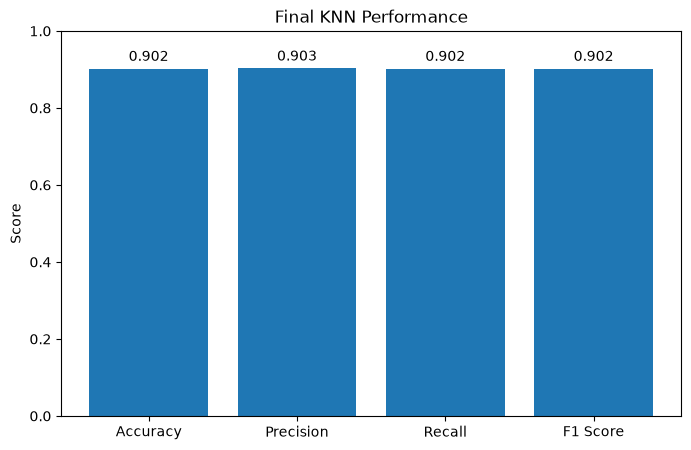

In [32]:
metrics = {
    'Accuracy': acc,
    'Precision': prec,
    'Recall': rec,
    'F1 Score': f1_score_value
}

plt.figure(figsize=(8,5))

plt.bar(metrics.keys(), metrics.values())

plt.ylim(0, 1)
plt.ylabel('Score')
plt.title('Final KNN Performance')

for i, value in enumerate(metrics.values()):
    plt.text(i, value + 0.02, f'{value:.3f}', ha='center')

plt.show()

In [33]:
import joblib

model_package = {
    'model': model,
    'scaler': scaler,
    'label_encoder': le,
    'features': features,
    'best_k': best_k
}

joblib.dump(model_package, 'knn_dry_bean_model.pkl')

print("Model saved successfully!")

Model saved successfully!


In [34]:
new_data = pd.DataFrame([{
    'Perimeter': 650,
    'AspectRation': 1.85,
    'roundness': 0.72,
    'ShapeFactor4': 0.99,
    'Solidity': 0.98,
    'Extent': 0.75
}])

new_scaled = scaler.transform(new_data[features])

prediction = model.predict(new_scaled)

predicted_class = le.inverse_transform(prediction)

print("Predicted Class:", predicted_class[0])

Predicted Class: HOROZ


In [35]:
features = [
    'Perimeter',
    'AspectRation',
    'roundness',
    'ShapeFactor4',
    'Solidity',
    'Extent'
]

df_final = df[features + ['Class']].copy()

df_final.to_csv(
    'dry_bean_selected_features.csv',
    index=False
)

print("File saved successfully!")
print(df_final.shape)
print(df_final.head())

File saved successfully!
(10594, 7)
    Perimeter  AspectRation  roundness  ShapeFactor4  Solidity    Extent  \
23    656.711      1.308864   0.921842      0.999091  0.987268  0.761823   
24    657.431      1.382816   0.920929      0.994950  0.989565  0.740936   
29    642.092      1.238051   0.969600      0.999515  0.992481  0.773877   
31    662.532      1.225284   0.911040      0.999481  0.986026  0.774848   
32    656.404      1.246471   0.928538      0.998843  0.987561  0.785246   

    Class  
23  SEKER  
24  SEKER  
29  SEKER  
31  SEKER  
32  SEKER  
